# CarDekho Used Car Price Prediction

This project builds a machine learning regression model to predict
the selling price of used cars using vehicle specifications and
seller-related information.

# importing the required packages

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px 
import warnings
from six.moves import urllib

warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Data Collection

The dataset contains used-car listings with vehicle specifications,
seller information, and selling price.

In [2]:
import os
import urllib.request

download_dir = './data/'

download_url = 'https://raw.githubusercontent.com/manishkr1754/CarDekho_Used_Car_Price_Prediction/main/notebooks/data/cardekho_dataset.csv'

os.makedirs(download_dir, exist_ok=True)

filename = os.path.basename(download_url)

download_file_path = os.path.join(download_dir, filename)

urllib.request.urlretrieve(download_url, download_file_path)

print('-' * 100)
print('Data with name ' + filename + ' Downloaded at ' + download_file_path)
print('-' * 100)

df = pd.read_csv(download_file_path, index_col=[0])

----------------------------------------------------------------------------------------------------
Data with name cardekho_dataset.csv Downloaded at ./data/cardekho_dataset.csv
----------------------------------------------------------------------------------------------------


## 2. Understanding the Dataset

Before building the model, we inspect the dataset structure,
dimensions, data types, unique values, missing values, and
basic statistics.

In [3]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [4]:
df.shape

(15411, 13)

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 15411 entries, 0 to 19543
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  str    
 1   brand              15411 non-null  str    
 2   model              15411 non-null  str    
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  str    
 6   fuel_type          15411 non-null  str    
 7   transmission_type  15411 non-null  str    
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), str(6)
memory usage: 1.6 MB


In [6]:
df.nunique()

car_name              121
brand                  32
model                 120
vehicle_age            24
km_driven            3688
seller_type             3
fuel_type               5
transmission_type       2
mileage               411
engine                110
max_power             342
seats                   8
selling_price        1086
dtype: int64

In [7]:
# defining the numerical and categorical features

numerical_features = [feature for feature in df.columns if df[feature].dtype != 'str' ]
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str' ]

print('Number of Numerical Features are: ',len(numerical_features))
print(numerical_features)
print()
print('Number of Categorical Features are: ',len(categorical_features))
print(categorical_features)


Number of Numerical Features are:  7
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Number of Categorical Features are:  6
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


In [8]:
# missing values in different columns

total=df.isnull().sum().sort_values(ascending=False)

percent=(df.isnull().sum()/df.isnull().count()*100).sort_values(ascending=False)

pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])

,Total,Percent
car_name,0,0.0
brand,0,0.0
model,0,0.0
vehicle_age,0,0.0
km_driven,0,0.0
seller_type,0,0.0
fuel_type,0,0.0
transmission_type,0,0.0
mileage,0,0.0
engine,0,0.0


In [9]:
print('Statistics of the Numerical Features:')
df.describe()

Statistics of the Numerical Features:


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [10]:
print('Statistics of the Categorical Features:')
df.describe(include='object')

Statistics of the Categorical Features:


,car_name,brand,model,seller_type,fuel_type,transmission_type
count,15411,15411,15411,15411,15411,15411
unique,121,32,120,3,5,2
top,Hyundai i20,Maruti,i20,Dealer,Petrol,Manual
freq,906,4992,906,9539,7643,12225


### Categorical Value Consistency

Categorical values are checked for inconsistent spelling or
duplicate representations that could create separate categories
for the same vehicle or attribute.

In [11]:
print(list(df['car_name'].unique()))
print()
print(list(df['brand'].unique()))
print()
print(list(df['model'].unique()))
print()
print(list(df['seller_type'].unique()))
print()
print(list(df['fuel_type'].unique()))
print()
print(list(df['transmission_type'].unique()))


# there is no spelling mistake or typo error so we are good to go 

['Maruti Alto', 'Hyundai Grand', 'Hyundai i20', 'Ford Ecosport', 'Maruti Wagon R', 'Hyundai i10', 'Hyundai Venue', 'Maruti Swift', 'Hyundai Verna', 'Renault Duster', 'Mini Cooper', 'Maruti Ciaz', 'Mercedes-Benz C-Class', 'Toyota Innova', 'Maruti Baleno', 'Maruti Swift Dzire', 'Volkswagen Vento', 'Hyundai Creta', 'Honda City', 'Mahindra Bolero', 'Toyota Fortuner', 'Renault KWID', 'Honda Amaze', 'Hyundai Santro', 'Mahindra XUV500', 'Mahindra KUV100', 'Maruti Ignis', 'Datsun RediGO', 'Mahindra Scorpio', 'Mahindra Marazzo', 'Ford Aspire', 'Ford Figo', 'Maruti Vitara', 'Tata Tiago', 'Volkswagen Polo', 'Kia Seltos', 'Maruti Celerio', 'Datsun GO', 'BMW 5', 'Honda CR-V', 'Ford Endeavour', 'Mahindra KUV', 'Honda Jazz', 'BMW 3', 'Audi A4', 'Tata Tigor', 'Maruti Ertiga', 'Tata Safari', 'Mahindra Thar', 'Tata Hexa', 'Land Rover Rover', 'Maruti Eeco', 'Audi A6', 'Mercedes-Benz E-Class', 'Audi Q7', 'BMW Z4', 'BMW 6', 'Jaguar XF', 'BMW X5', 'MG Hector', 'Honda Civic', 'Isuzu D-Max', 'Porsche Cayenne'

In [12]:
print('The percentage of each Category in Categorical Columns: ')

for col in categorical_features:
    print(df[col].value_counts(normalize=True)*100)
    print('-'*100)

The percentage of each Category in Categorical Columns: 
car_name
Hyundai i20              5.878918
Maruti Swift Dzire       5.775096
Maruti Swift             5.067809
Maruti Alto              5.048342
Honda City               4.912076
                           ...   
Mercedes-AMG C           0.006489
Rolls-Royce Ghost        0.006489
Maserati Quattroporte    0.006489
Isuzu MUX                0.006489
Force Gurkha             0.006489
Name: proportion, Length: 121, dtype: float64
----------------------------------------------------------------------------------------------------
brand
Maruti           32.392447
Hyundai          19.349815
Honda             9.635974
Mahindra          6.560249
Toyota            5.145675
Ford              5.126209
Volkswagen        4.023100
Renault           3.478035
BMW               2.848615
Tata              2.790215
Mercedes-Benz     2.186750
Skoda             2.167283
Audi              1.245863
Datsun            1.103108
Jaguar            0.382843
La

## 3. Exploratory Data Analysis

Exploratory analysis is used to understand the distribution of
vehicle prices and investigate how vehicle characteristics relate
to selling price.

### 3.1 Univariate Analysis

#### Numerical Features

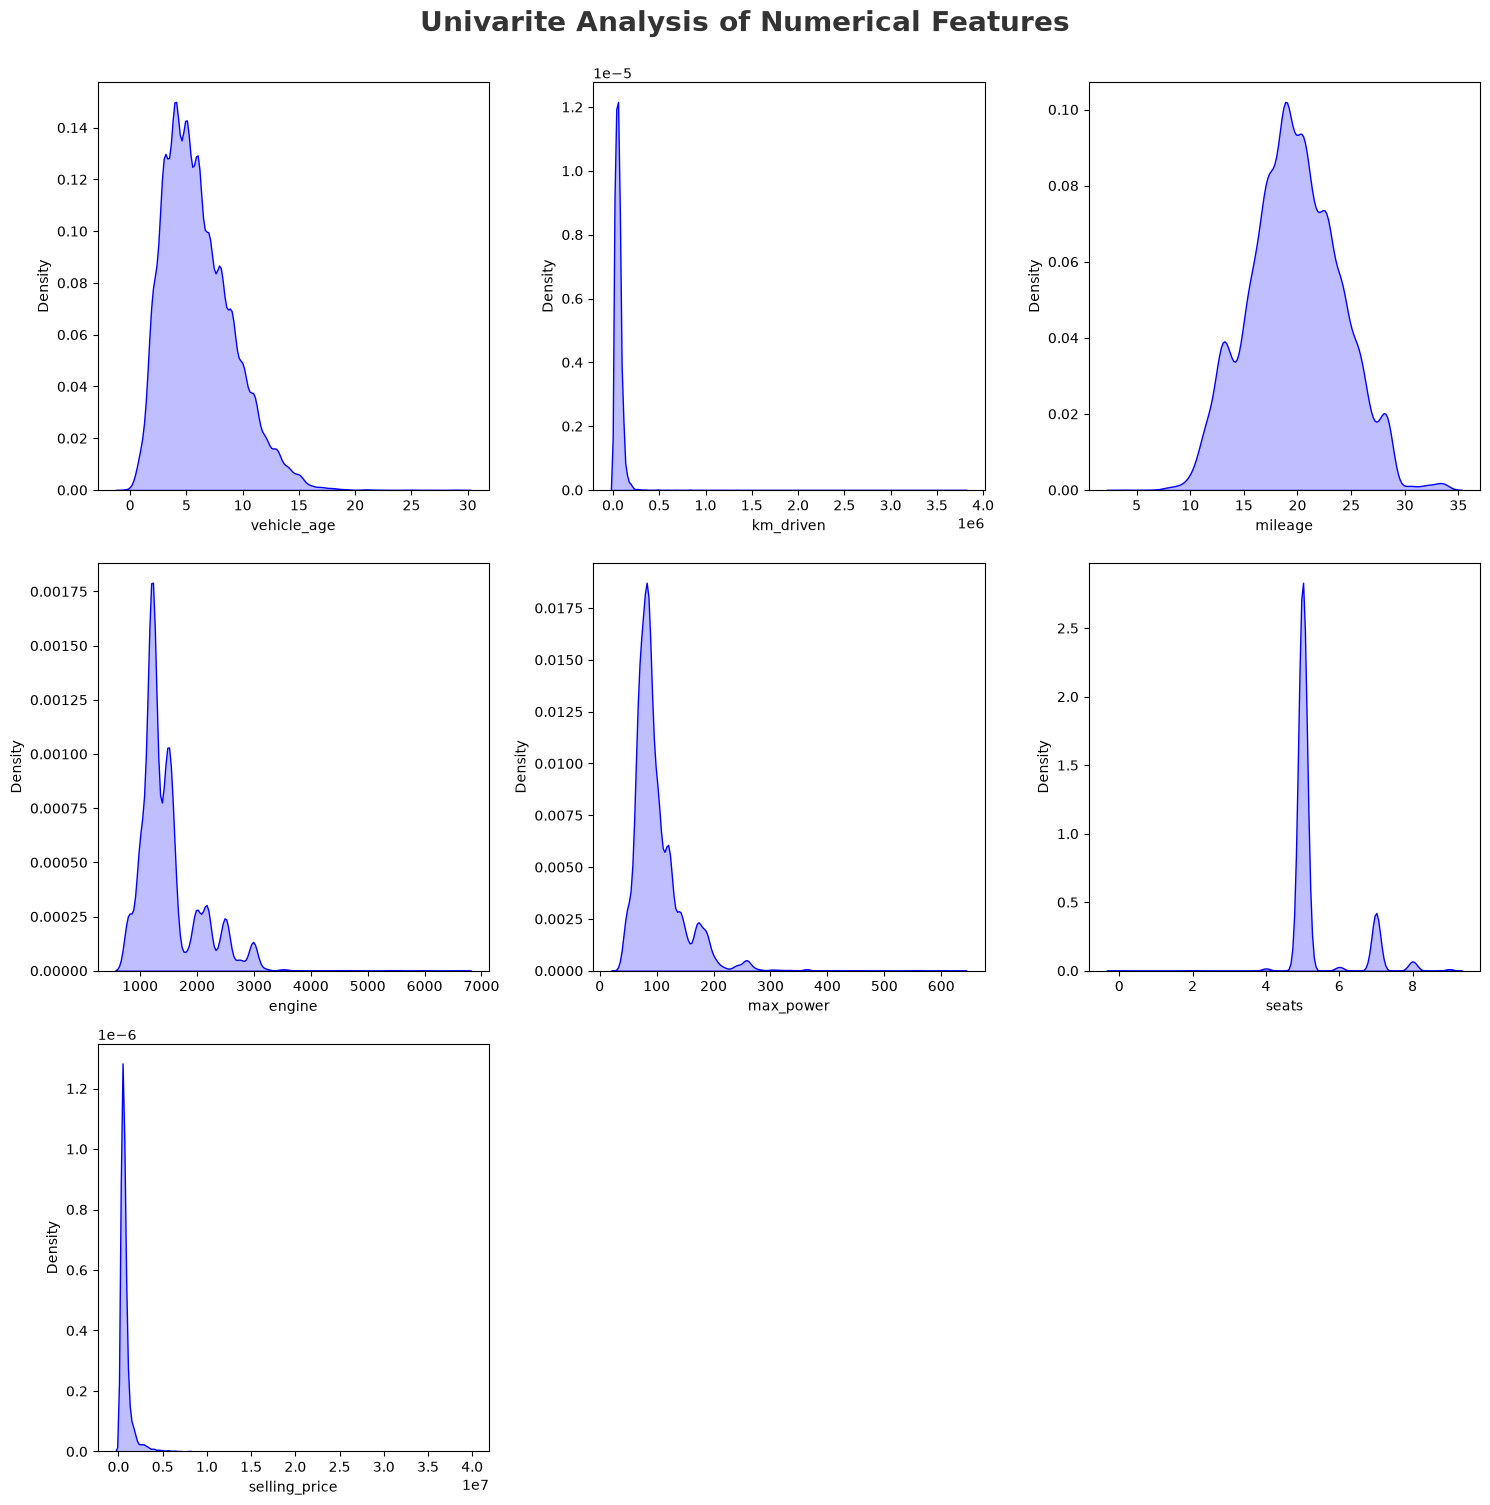

In [13]:
plt.figure(figsize=(15,15))

plt.suptitle('Univarite Analysis of Numerical Features', fontsize = 20 , fontweight = 'bold', alpha = 0.8, y = 1.0)

for i in range(0,len(numerical_features)):
    plt.subplot(3,3,i+1)
    sns.kdeplot(x = df[numerical_features[i]], shade = True, color= 'b')
    plt.xlabel(numerical_features[i])
    plt.tight_layout()

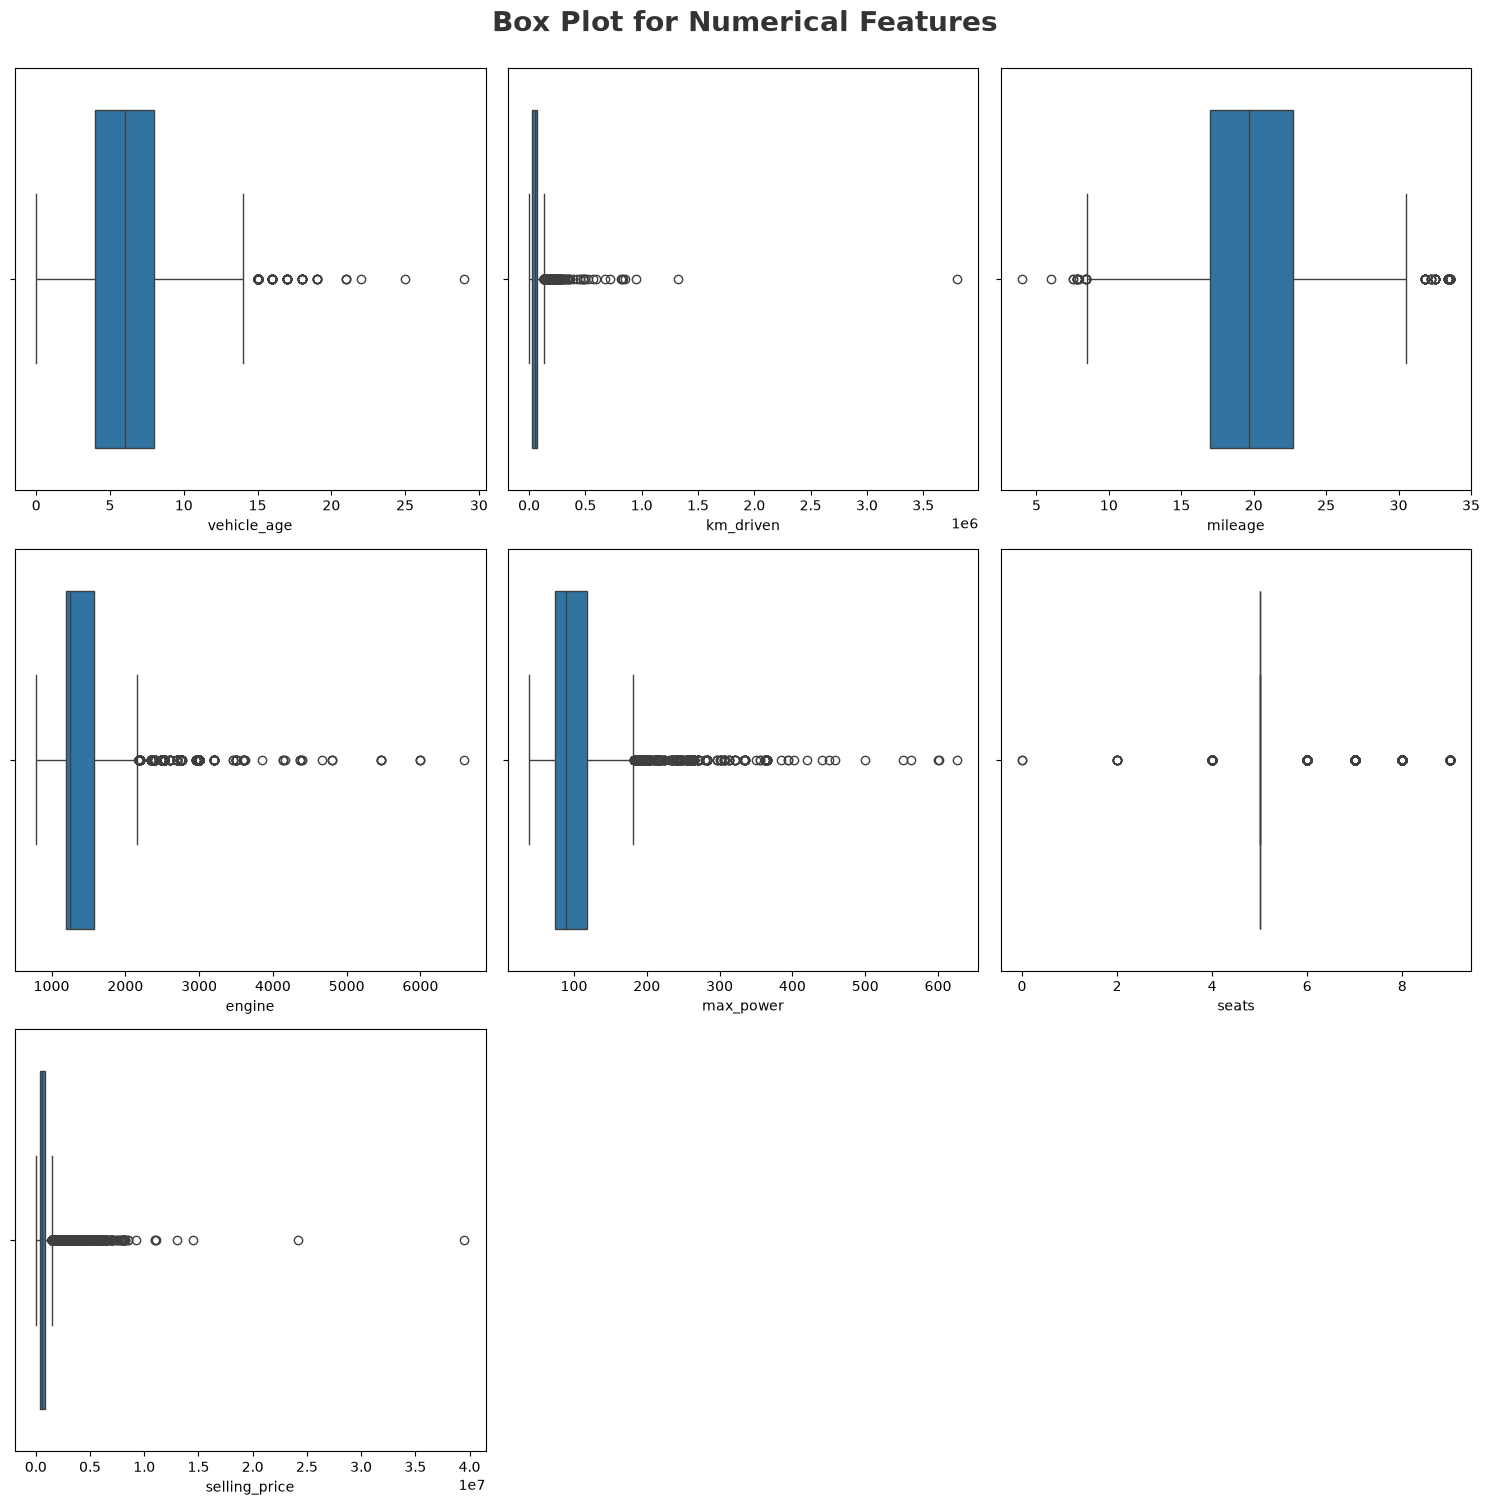

In [14]:
plt.figure(figsize=(15,15))

plt.suptitle('Box Plot for Numerical Features', fontsize = 20 , fontweight = 'bold', alpha = 0.8, y = 1.0)

for i in range(0,len(numerical_features)):
    plt.subplot(3,3,i+1)
    sns.boxplot(x = df[numerical_features[i]])
    plt.xlabel(numerical_features[i])
    plt.tight_layout()

### Observation

Several numerical variables show right-skewed distributions.
Vehicle age and kilometers driven also show meaningful variation
across the dataset.

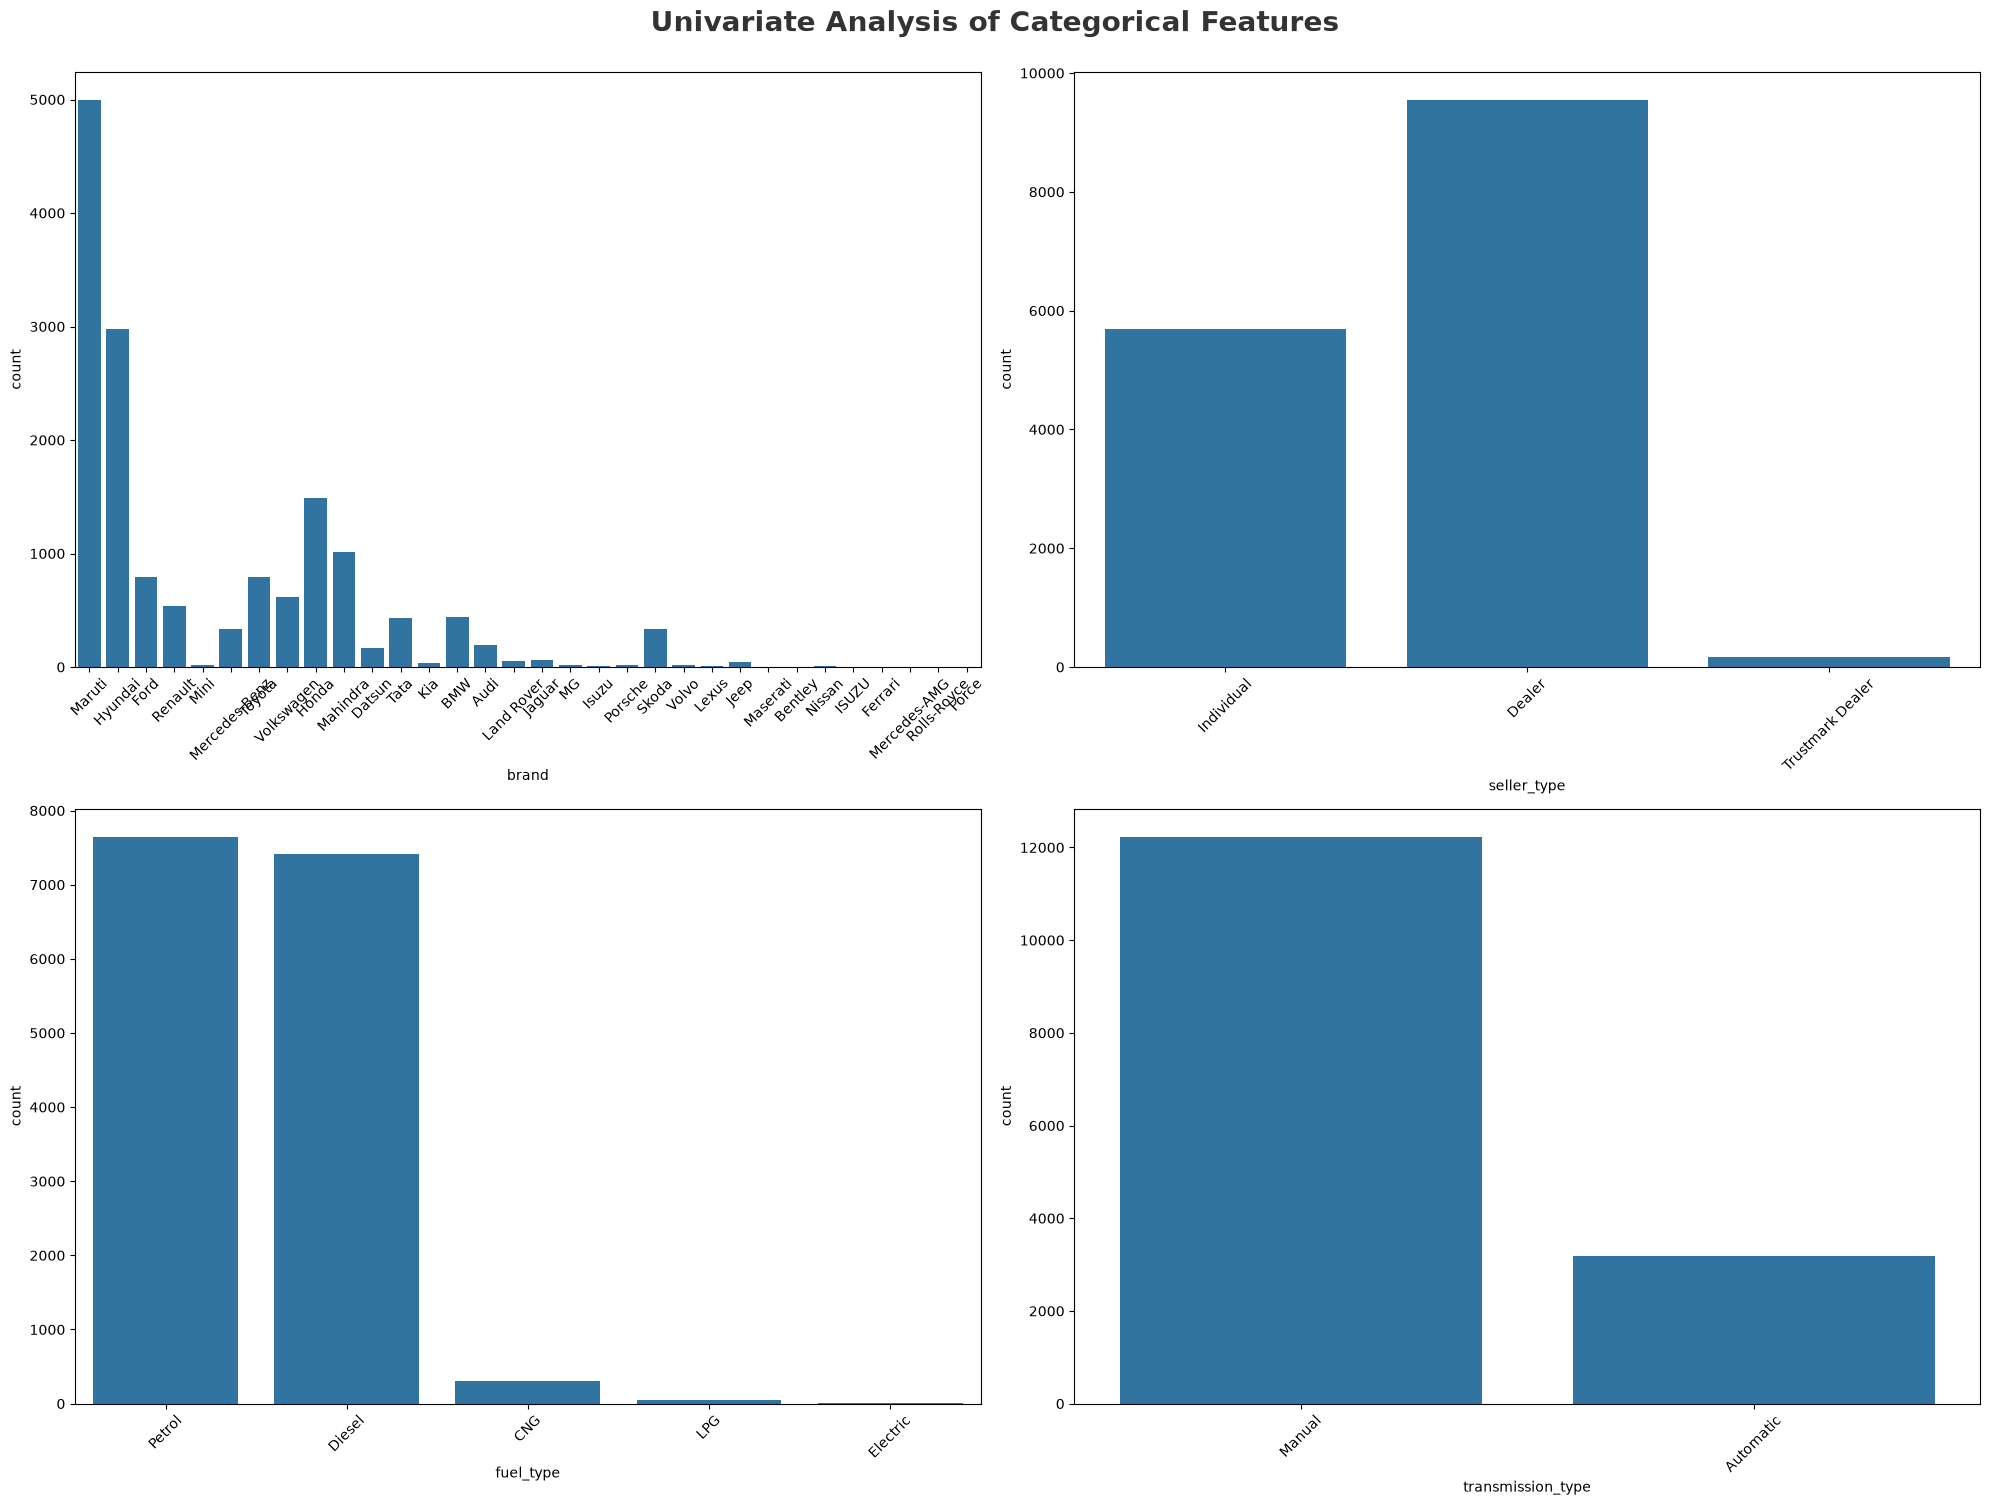

In [15]:
plt.figure(figsize=(20, 15))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.0)

cat1 = [ 'brand', 'seller_type', 'fuel_type', 'transmission_type']
for i in range(0, len(cat1)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=df[cat1[i]])
    plt.xlabel(cat1[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

In [16]:
continuous_features=[feature for feature in numerical_features if len(df[feature].unique())>=10]
print('Num of continuos features:',continuous_features)

Num of continuos features: ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'selling_price']


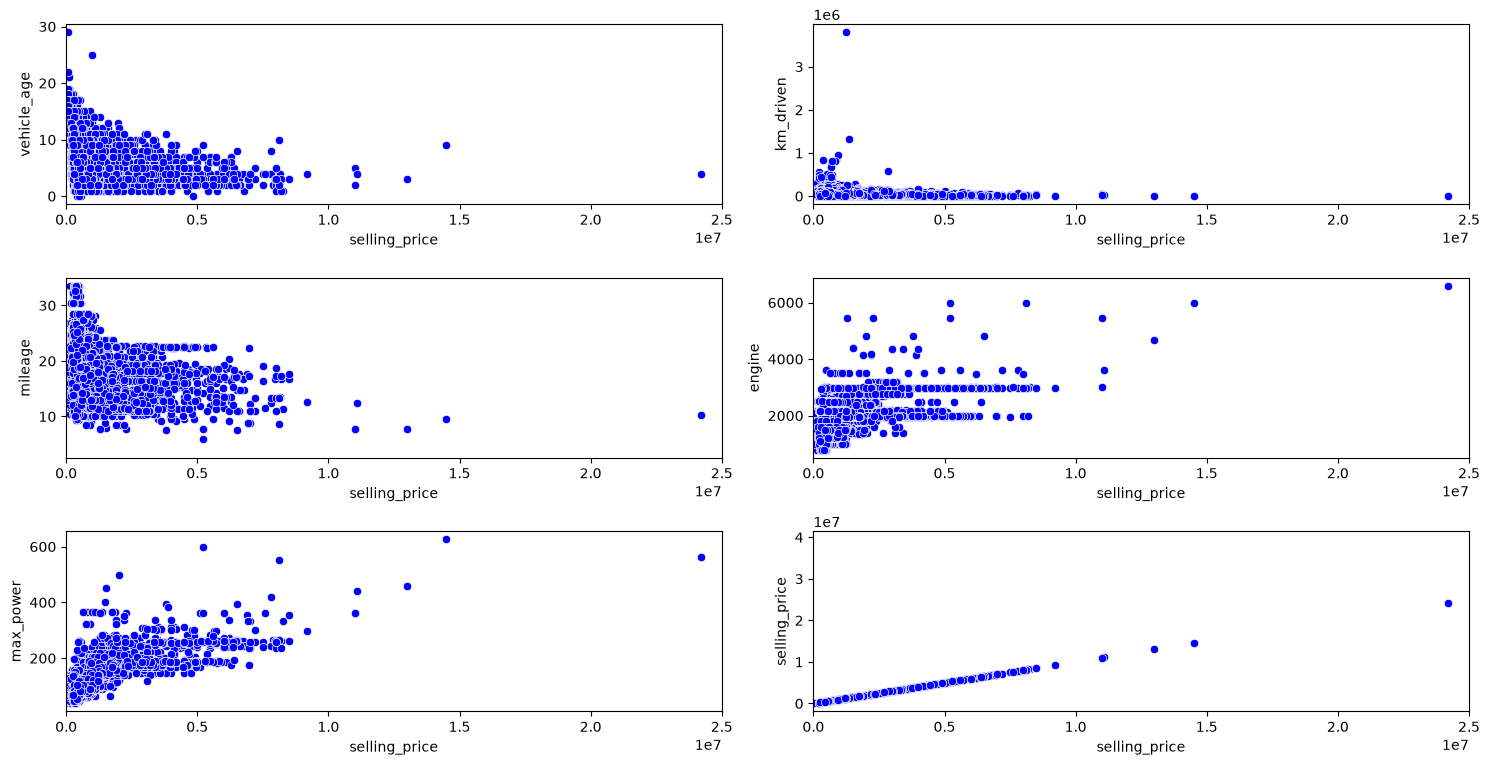

In [17]:
fig = plt.figure(figsize=(15, 20))

for i in range(0, len(continuous_features)):
    ax = plt.subplot(8, 2, i+1)

    sns.scatterplot(data= df ,x='selling_price', y=continuous_features[i], color='b')
    plt.xlim(0,25000000) # Limit to 25 lakhs Rupees to view clean
    plt.tight_layout()

### Observation

Vehicle age and kilometers driven show a negative relationship
with selling price, while engine capacity and maximum power show
positive relationships with price.

### 3.2 Multivariate Analysis

In [18]:
df[numerical_features].corr()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
vehicle_age,1.000000,0.333891,-0.257394,0.098965,0.005208,0.030791,-0.241851
km_driven,0.333891,1.000000,-0.105239,0.192885,0.044421,0.192830,-0.080030
mileage,-0.257394,-0.105239,1.000000,-0.632987,-0.533128,-0.440280,-0.305549
engine,0.098965,0.192885,-0.632987,1.000000,0.807368,0.551236,0.585844
max_power,0.005208,0.044421,-0.533128,0.807368,1.000000,0.172257,0.750236
seats,0.030791,0.192830,-0.440280,0.551236,0.172257,1.000000,0.115033
selling_price,-0.241851,-0.080030,-0.305549,0.585844,0.750236,0.115033,1.000000


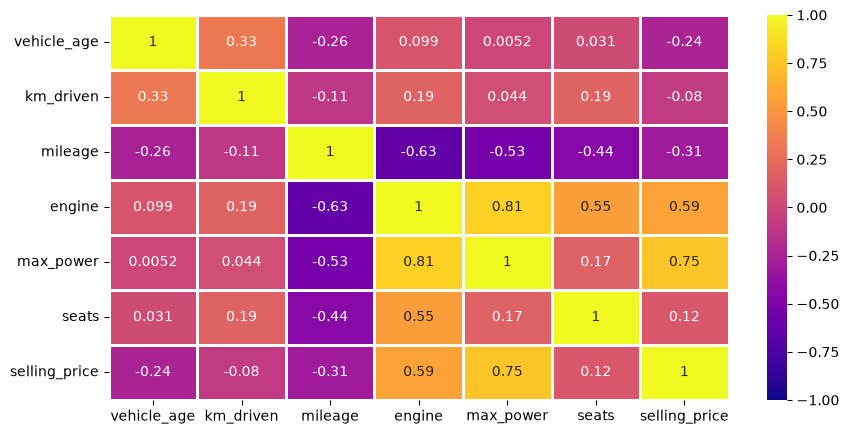

In [19]:
plt.figure(figsize=(10,5))
sns.heatmap(data = df[numerical_features].corr(), annot= True, cmap= 'plasma', vmin= -1 , vmax= 1, linecolor='white', linewidths=2)
plt.show()

### Observation

Engine capacity and maximum power show a strong relationship.
Maximum power also has a strong relationship with selling price.

### Categorical Feature Association

Categorical features are checked for their statistical association
with the target variable.

In [20]:
from scipy.stats import chi2_contingency
chi2_test = []

for feature in categorical_features:
    if chi2_contingency(pd.crosstab(df['selling_price'], df[feature]))[1] < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')
test_result = pd.DataFrame(data=[categorical_features, chi2_test]).T
test_result.columns = ['Categorical Features', 'Hypothesis Result']

test_result

,Categorical Features,Hypothesis Result
0,car_name,Reject Null Hypothesis
1,brand,Reject Null Hypothesis
2,model,Reject Null Hypothesis
3,seller_type,Reject Null Hypothesis
4,fuel_type,Reject Null Hypothesis
5,transmission_type,Reject Null Hypothesis


### 3.3 Target Variable Analysis

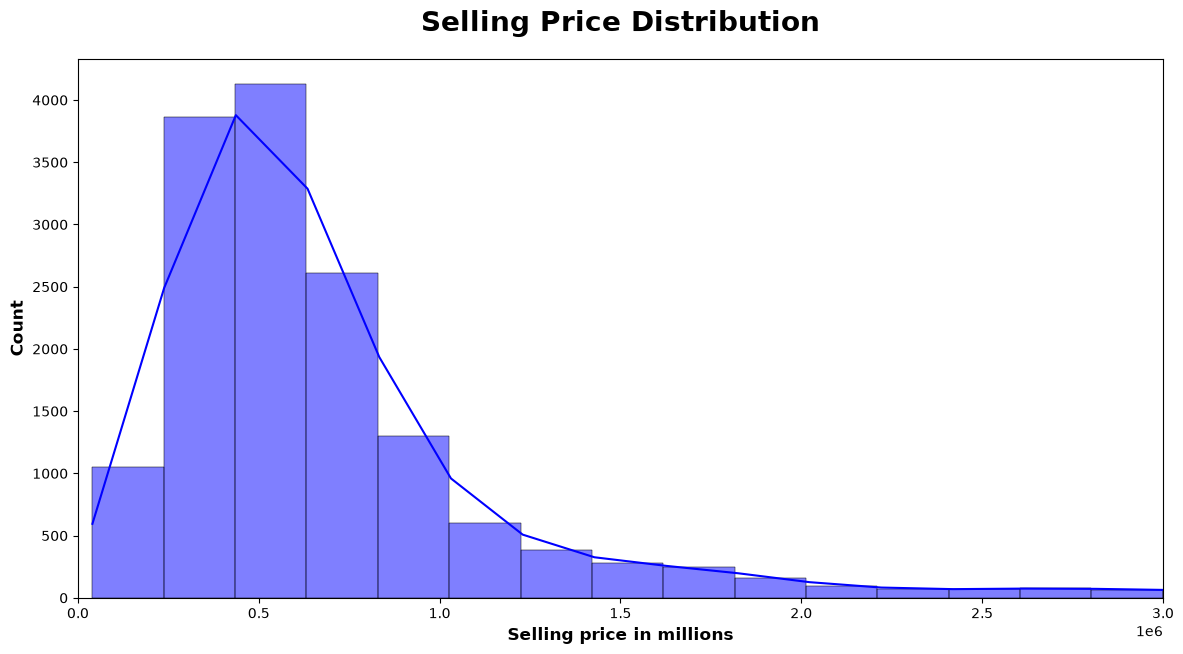

In [21]:
plt.subplots(figsize=(14,7))
sns.histplot(df.selling_price, bins=200, kde=True, color = 'b')
plt.title("Selling Price Distribution", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Selling price in millions", weight="bold", fontsize=12)
plt.xlim(0,3000000)
plt.show()

### Observation

The selling price distribution is right-skewed, with most vehicles concentrated in the lower price range. A smaller number of vehicles have considerably higher selling prices, resulting in a long right tail.

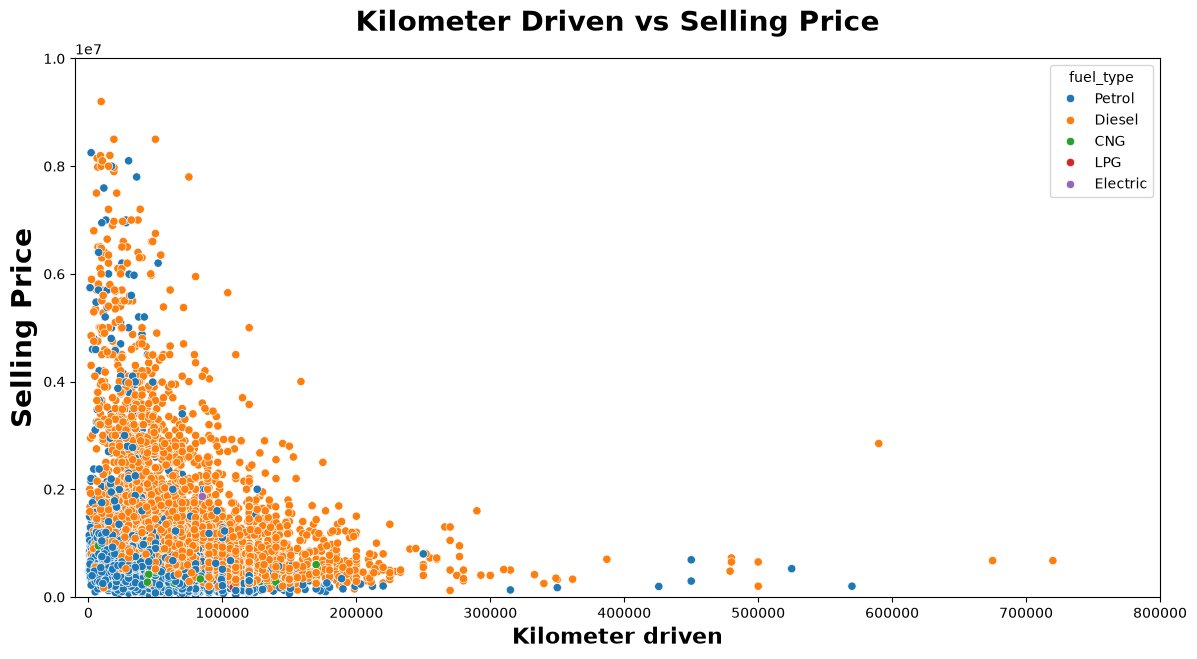

In [22]:
plt.subplots(figsize=(14,7))
sns.scatterplot(x="km_driven", y='selling_price', data=df,ec = "white",color='b', hue='fuel_type')
plt.title("Kilometer Driven vs Selling Price", weight="bold",fontsize=20, pad=20)
plt.ylabel("Selling Price", weight="bold", fontsize=20)
plt.xlim(-10000,800000) #used limit for better visualization
plt.ylim(-10000,10000000)
plt.xlabel("Kilometer driven", weight="bold", fontsize=16)
plt.show()

### Observation

The plot shows a general negative relationship between kilometers driven and selling price. Vehicles with lower kilometers driven tend to have higher selling prices, while vehicles with higher kilometer driven are generally priced lower. The spread also indicates that other factors influence the selling price.

In [23]:
fuel = df.groupby('fuel_type')['selling_price'].median().sort_values(ascending=False)
fuel.to_frame()

,selling_price
fuel_type,
Electric,1857500.0
Diesel,700000.0
Petrol,460000.0
CNG,370000.0
LPG,182500.0


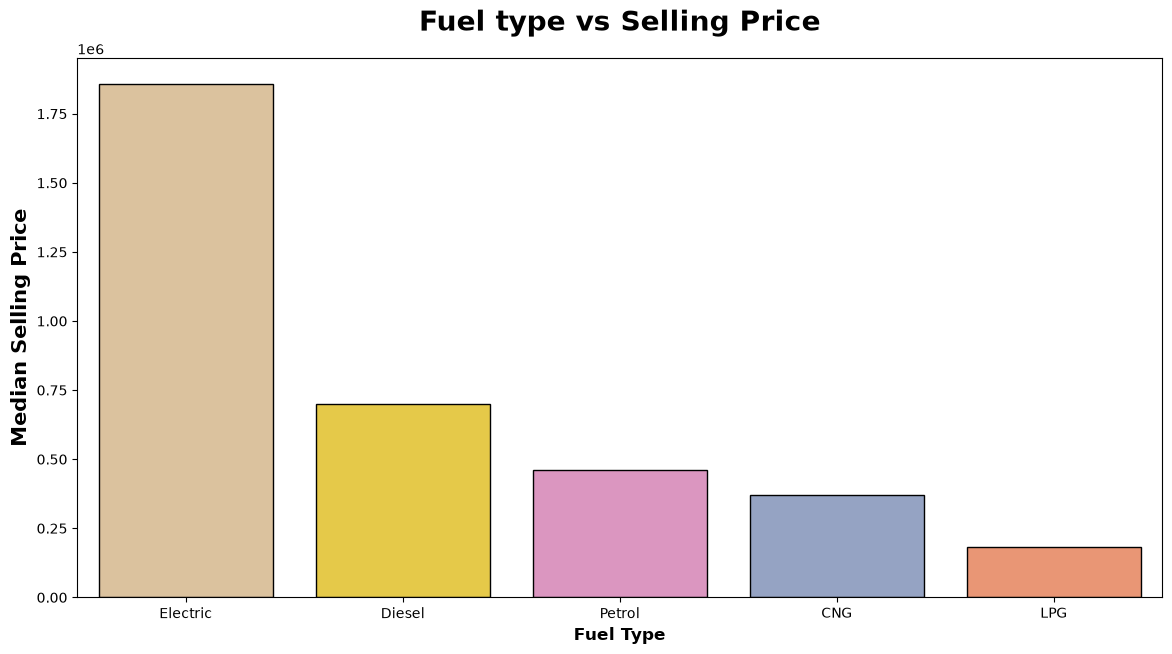

In [24]:
plt.subplots(figsize=(14,7))
sns.barplot(x=fuel.index, y=fuel.values, ec = "black", palette="Set2_r")
plt.title("Fuel type vs Selling Price", weight="bold",fontsize=20, pad=20)
plt.ylabel("Median Selling Price", weight="bold", fontsize=15)
plt.xlabel("Fuel Type", weight="bold", fontsize=12)
plt.show()

### Observation

The median selling price varies considerably across fuel types. Electric vehicles have the highest median selling price in the dataset, followed by diesel and petrol vehicles, while LPG vehicles have the lowest median selling price.

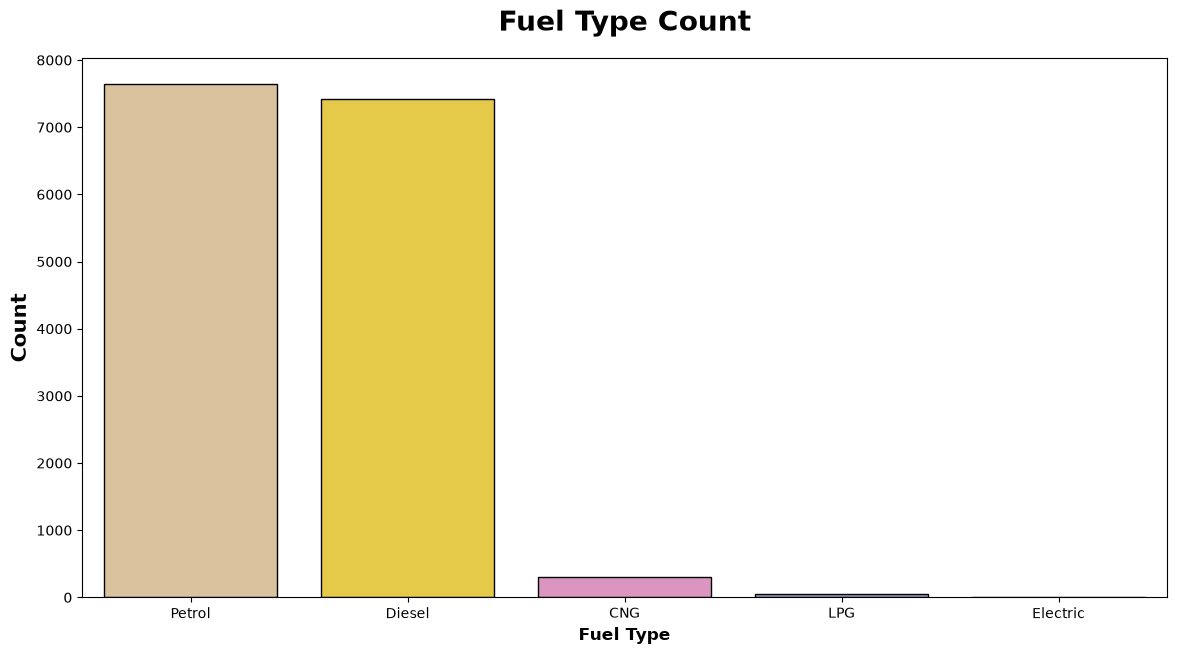

In [25]:
plt.subplots(figsize=(14,7))
sns.countplot(x=df.fuel_type, ec = "black", palette="Set2_r")
plt.title("Fuel Type Count", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=15)
plt.xlabel("Fuel Type", weight="bold", fontsize=12)
plt.show()

### Observation

Petrol and diesel vehicles make up the majority of the dataset, with petrol having a slightly higher number of listings. CNG, LPG, and electric vehicles represent a much smaller portion of the dataset.

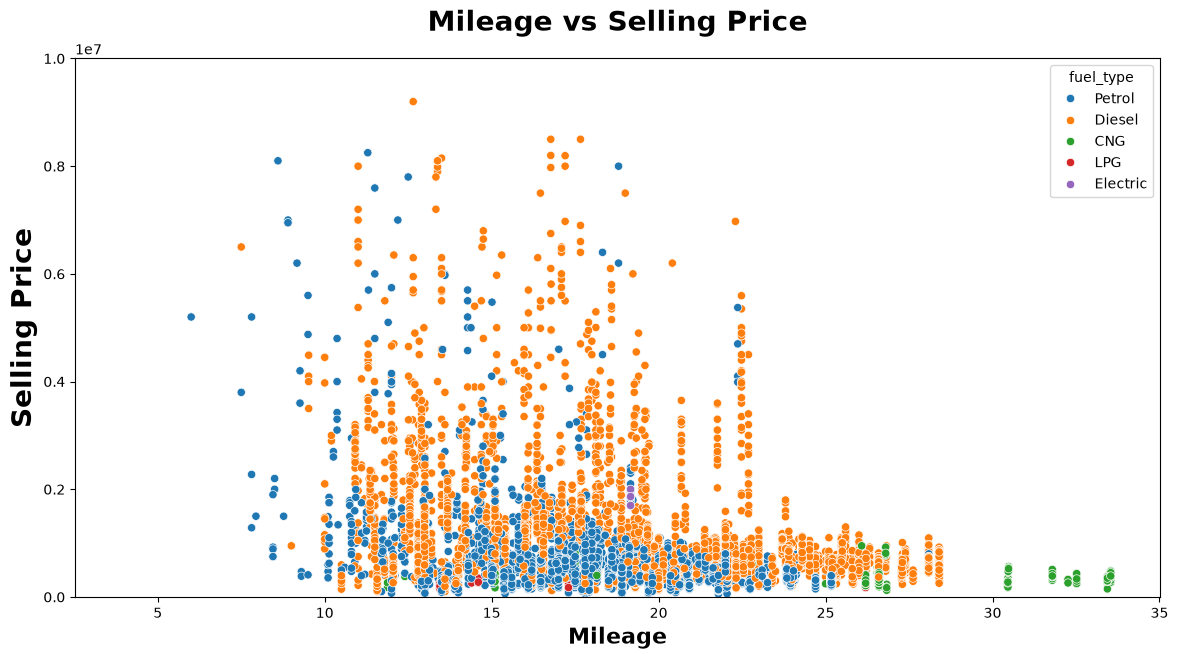

In [26]:
plt.subplots(figsize=(14,7))
sns.scatterplot(x="mileage", y='selling_price', data=df,ec = "white",color='b', hue='fuel_type')
plt.title("Mileage vs Selling Price", weight="bold",fontsize=20, pad=20)
plt.ylabel("Selling Price", weight="bold", fontsize=20)
plt.ylim(-10000,10000000)
plt.xlabel("Mileage", weight="bold", fontsize=16)
plt.show()

### Observation

The plot shows that most vehicles have a mileage between approximately 10 and 25 kmpl. Selling prices are widely distributed within this range, indicating that mileage alone does not determine the selling price. Diesel and petrol vehicles form the majority of the observations.

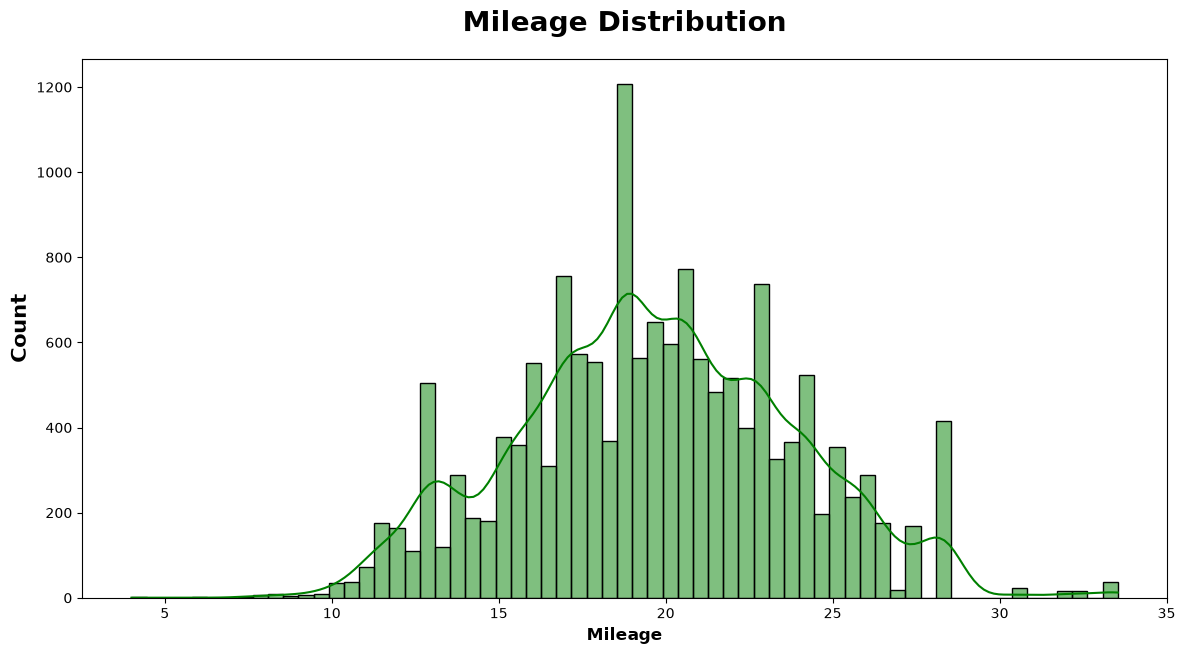

In [27]:
plt.subplots(figsize=(14,7))
sns.histplot(x=df.mileage, ec = "black", color='g', kde=True)
plt.title("Mileage Distribution", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=15)
plt.xlabel("Mileage", weight="bold", fontsize=12)
plt.show()

### Observation

The mileage distribution is concentrated mainly between approximately 15 and 25 kmpl, with the highest concentration around 18–21 kmpl. Very low and very high mileage values occur less frequently in the dataset.

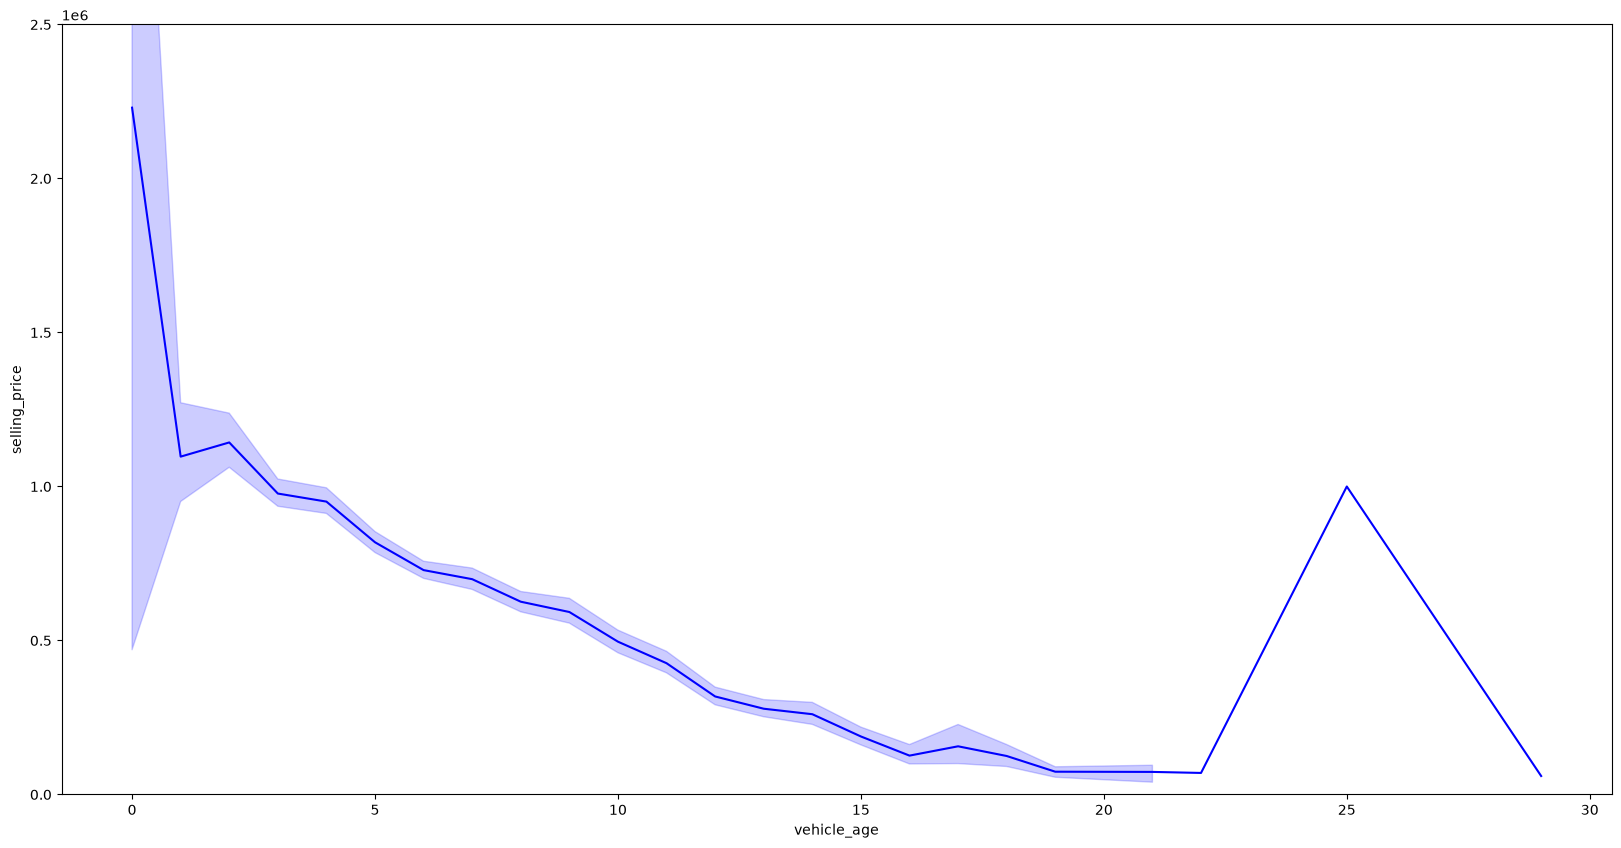

In [28]:
plt.subplots(figsize=(20,10))
sns.lineplot(x='vehicle_age',y='selling_price',data=df,color='b')
plt.ylim(0,2500000)
plt.show()

### Observation – Vehicle Age vs Selling Price

The graph shows a clear overall relationship between vehicle age and selling price. In general, newer vehicles tend to have higher selling prices, while the selling price decreases as the vehicle gets older.

The average selling price is relatively high for newer vehicles and gradually declines with increasing vehicle age. The fluctuations observed at higher vehicle ages are likely due to fewer vehicles being available in those age groups.

**Insight:** Vehicle age is an important factor influencing the resale value of a car, with older vehicles generally having lower selling prices.

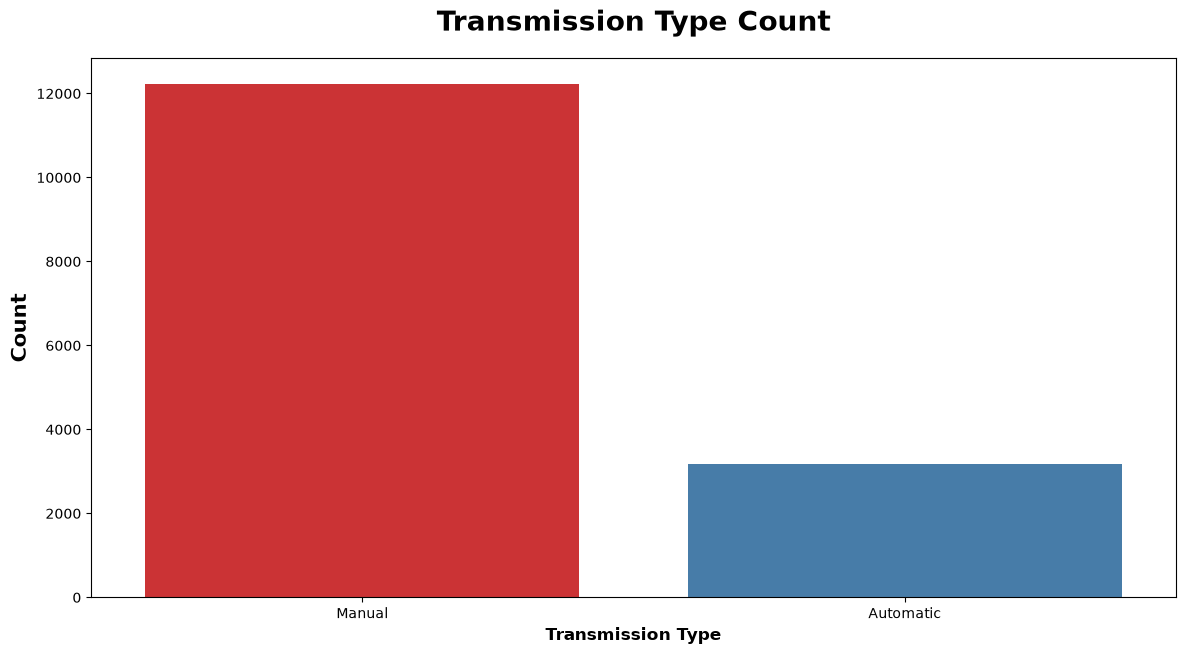

In [29]:
plt.subplots(figsize=(14,7))
sns.countplot(x='transmission_type', data=df,palette="Set1")
plt.title("Transmission Type Count", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=15)
plt.xlabel("Transmission Type", weight="bold", fontsize=12)
plt.show() 


### Observation – Transmission Type Distribution

The dataset contains significantly more manual transmission vehicles than automatic transmission vehicles.

Manual vehicles represent the majority of the observations, while automatic vehicles form a smaller portion of the dataset.

**Insight:** The dataset is dominated by manual transmission vehicles, indicating that transmission type is not evenly distributed in the available data.

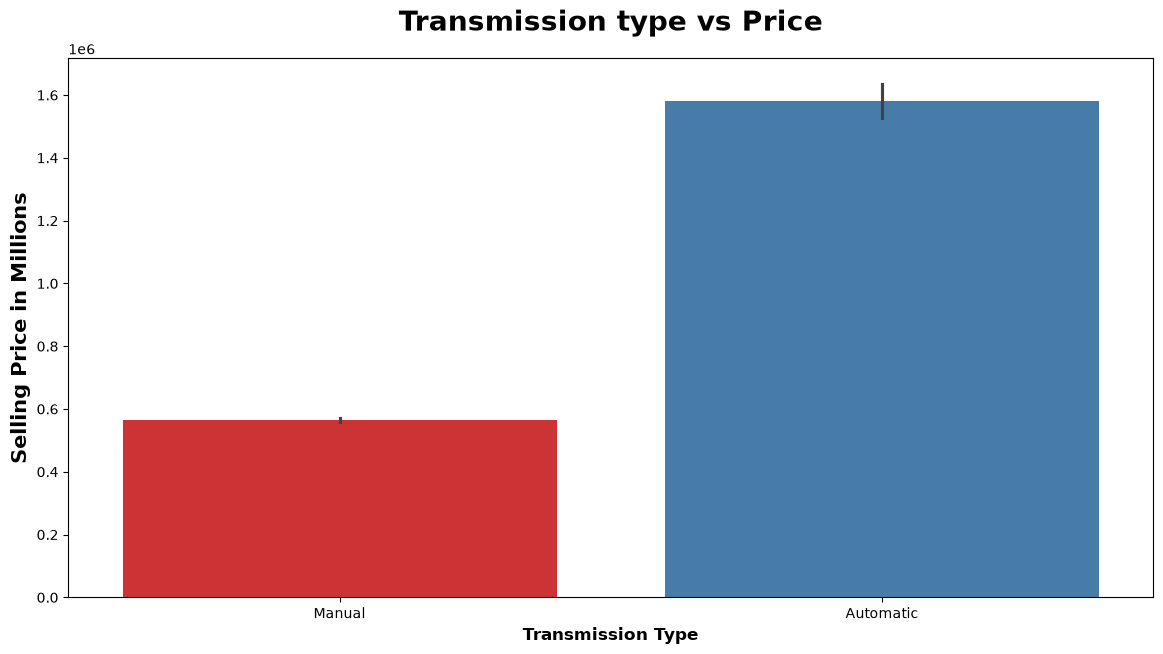

In [30]:
plt.subplots(figsize=(14,7))
sns.barplot(x='transmission_type', y='selling_price', data=df,palette="Set1")
plt.title("Transmission type vs Price", weight="bold",fontsize=20, pad=20)
plt.ylabel("Selling Price in Millions", weight="bold", fontsize=15)
plt.xlabel("Transmission Type", weight="bold", fontsize=12)
plt.show() 

### Observation – Transmission Type vs Selling Price

The graph shows a noticeable difference in the median selling price between transmission types. Automatic transmission vehicles have a considerably higher median selling price compared with manual transmission vehicles.

This indicates that transmission type may have an influence on the resale price. However, the difference may also be related to other factors such as vehicle age, engine capacity, brand, and overall vehicle characteristics.

**Insight:** Transmission type appears to be associated with selling price, with automatic vehicles having a higher median selling price in this dataset.

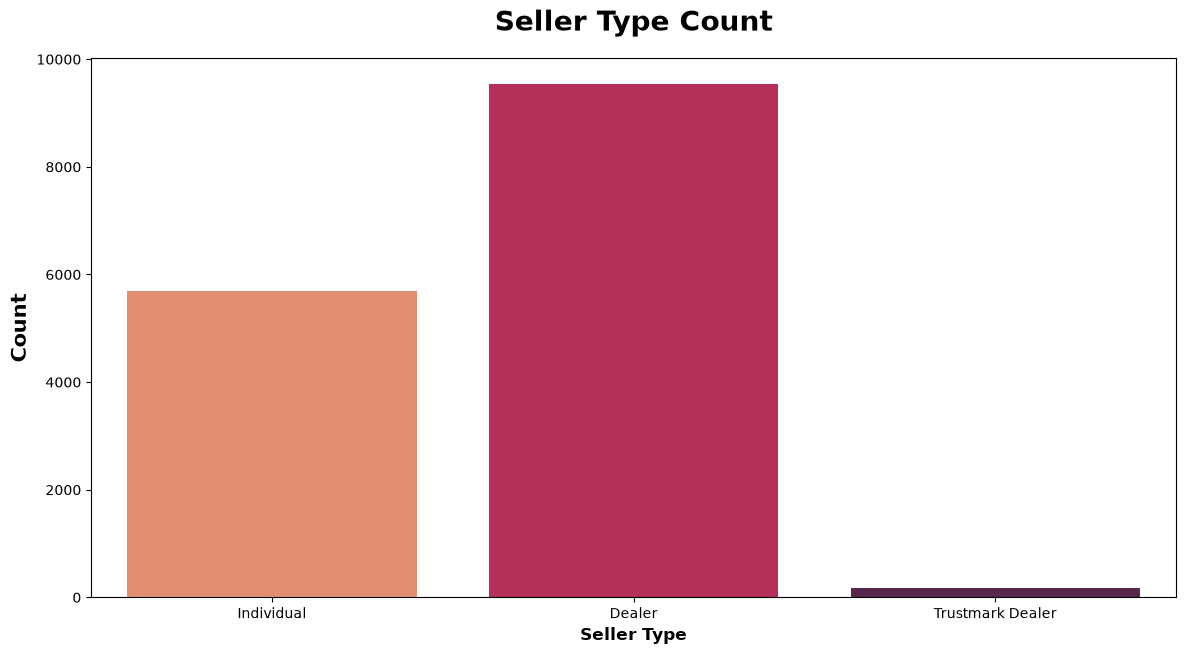

In [31]:
plt.subplots(figsize=(14,7))
sns.countplot(x='seller_type', data=df,palette="rocket_r")
plt.title("Seller Type Count", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=15)
plt.xlabel("Seller Type", weight="bold", fontsize=12)
plt.show() 

### Observation – Seller Type Distribution

The dataset contains three seller categories: Individual, Dealer, and Trustmark Dealer.

Dealer listings form the largest group, followed by Individual sellers. Trustmark Dealer listings represent only a small portion of the dataset.

**Insight:** The dataset is mainly composed of vehicles listed by dealers and individual sellers, while Trustmark Dealer vehicles are comparatively less represented.

In [32]:
dealer = df.groupby('seller_type')['selling_price'].median().sort_values(ascending=False)
dealer.to_frame()

,selling_price
seller_type,
Dealer,591000.0
Trustmark Dealer,540000.0
Individual,507000.0


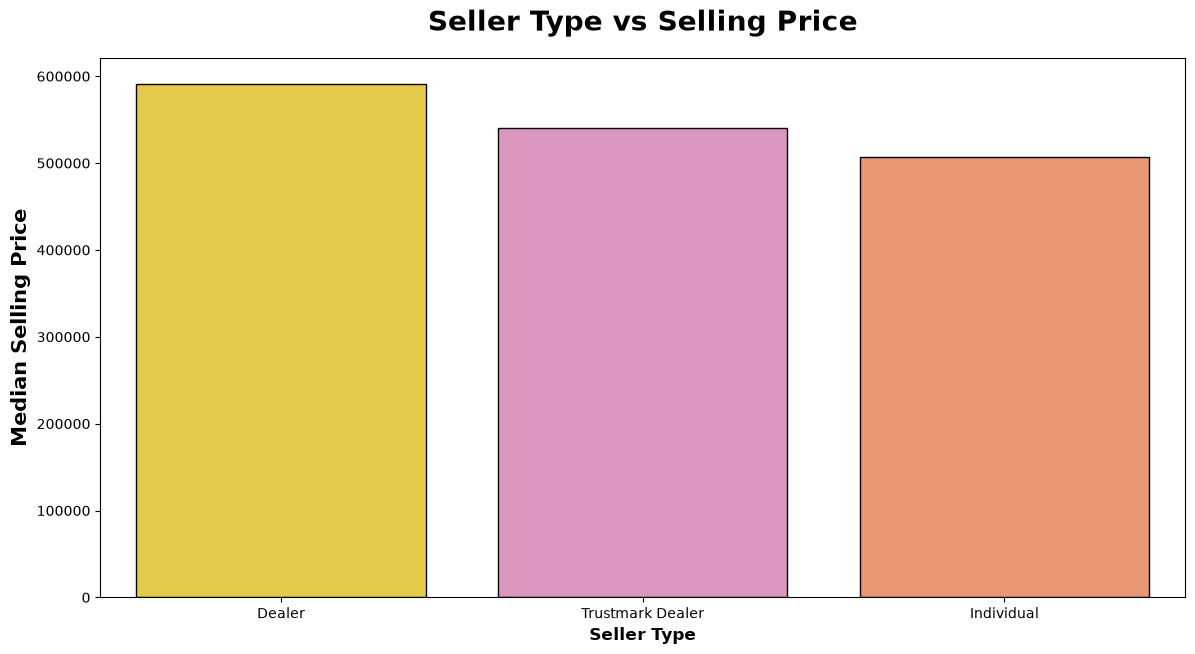

In [33]:
plt.subplots(figsize=(14,7))
sns.barplot(x=dealer.index, y=dealer.values, ec = "black", palette="Set2_r")
plt.title("Seller Type vs Selling Price", weight="bold",fontsize=20, pad=20)
plt.ylabel("Median Selling Price", weight="bold", fontsize=15)
plt.xlabel("Seller Type", weight="bold", fontsize=12)
plt.show()

### Observation – Seller Type vs Selling Price

The graph shows differences in the median selling price across seller types. Dealer-listed vehicles have the highest median selling price, followed by Trustmark Dealer vehicles, while Individual sellers have a comparatively lower median selling price.

This difference may be influenced by other vehicle characteristics such as vehicle age, brand, engine size, mileage, and vehicle condition.

**Insight:** Seller type shows an association with selling price in the dataset, making it a potentially useful categorical feature for the prediction model.

## Final EDA Observations

The Exploratory Data Analysis provided several important insights into the factors associated with vehicle selling prices.

- The **selling price distribution is right-skewed**, with most vehicles concentrated in the lower price range and a smaller number of high-priced vehicles.
- **Vehicle age shows a general negative relationship with selling price**. Newer vehicles tend to have higher selling prices, while the price generally decreases as vehicle age increases.
- **Mileage also shows an overall negative relationship with selling price**. Vehicles with higher mileage generally tend to have lower selling prices, although the relationship varies across different fuel types.
- **Fuel type has noticeable differences in selling prices**. Electric vehicles show a higher median selling price in this dataset, while LPG vehicles have a comparatively lower median selling price. However, the number of observations differs considerably between fuel categories.
- The dataset contains substantially more **Petrol and Diesel vehicles** than CNG, LPG, and Electric vehicles. Therefore, the less-represented fuel categories should be considered carefully during model training.
- **Manual transmission vehicles are much more common than automatic vehicles** in the dataset. The median selling price of automatic vehicles is considerably higher than that of manual vehicles.
- **Seller type is also unevenly distributed**, with Dealer listings forming the largest group, followed by Individual sellers, while Trustmark Dealer listings are comparatively few.
- The median selling price varies across **seller types**, with Dealer vehicles showing a higher median selling price than Individual vehicles in the dataset.
- Several variables therefore show meaningful relationships with the target variable **Selling Price**, particularly **vehicle age, mileage, fuel type, transmission type, and seller type**.

### Overall Conclusion

The EDA indicates that vehicle selling price is influenced by a combination of vehicle characteristics and categorical factors rather than by a single variable. The observed relationships and differences across categories provide a useful basis for **feature selection, preprocessing, and machine learning model development**.

The analysis also highlights the presence of **skewed distributions, outliers, and imbalanced categorical groups**, which should be considered during the preprocessing and model-building stages.

## 4. Feature Engineering

The dataset is prepared for machine learning by removing
unnecessary features and converting categorical variables into
numerical representations.

### Removing High-Cardinality Categorical Features

`car_name`, `brand`, and `model` contain many categorical values.
For this version of the model, these columns are excluded to keep
the feature space manageable and avoid introducing a large number
of sparse encoded features.

In [34]:
df_model=df.copy()

df_model.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [35]:
df_model.drop(labels=['car_name','brand','model'],axis=1,inplace=True)

df_model.head()

,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [36]:
# Converting Categorical Columns into numerical
# Using One Hot Encoding (get_dummies) to convert categorical variables to numerical

In [37]:
df_model=pd.get_dummies(df_model,dtype=float)
df_model.head()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,5,20000,18.90,1197,82.00,5,550000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,11,60000,17.00,1197,80.00,5,215000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,9,37000,20.92,998,67.10,5,226000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,6,30000,22.77,1498,98.59,5,570000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [38]:
df_model.dtypes

vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
selling_price                     int64
seller_type_Dealer              float64
seller_type_Individual          float64
seller_type_Trustmark Dealer    float64
fuel_type_CNG                   float64
fuel_type_Diesel                float64
fuel_type_Electric              float64
fuel_type_LPG                   float64
fuel_type_Petrol                float64
transmission_type_Automatic     float64
transmission_type_Manual        float64
dtype: object

In [39]:
X=df_model.drop('selling_price',axis=1)      # Feature Matrix
X

,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,5,20000,18.90,1197,82.00,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,11,60000,17.00,1197,80.00,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,9,37000,20.92,998,67.10,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,6,30000,22.77,1498,98.59,5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19537,9,10723,19.81,1086,68.05,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
19540,2,18000,17.50,1373,91.10,7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
19541,6,67000,21.14,1498,103.52,5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
19542,5,3800000,16.00,2179,140.00,7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [40]:
y=df_model['selling_price']    # Target Variable
y

0         120000
1         550000
2         215000
3         226000
4         570000
          ...   
19537     250000
19540     925000
19541     425000
19542    1225000
19543    1200000
Name: selling_price, Length: 15411, dtype: int64

## 5. Feature Importance

Extra Trees Regressor is used to estimate the relative importance
of the available features.

In [41]:
from sklearn.ensemble import ExtraTreesRegressor

model = ExtraTreesRegressor()

print(model.fit(X,y))

ExtraTreesRegressor()


In [42]:
print(model.feature_importances_)

[1.66352682e-01 4.61060049e-02 6.57400985e-02 1.31915813e-01
 3.75934152e-01 1.58408627e-02 3.00290480e-03 4.15768650e-03
 2.50359198e-05 4.87696078e-05 7.25354230e-03 1.98282578e-05
 1.93373996e-06 2.25381127e-02 7.12935871e-02 8.97689867e-02]


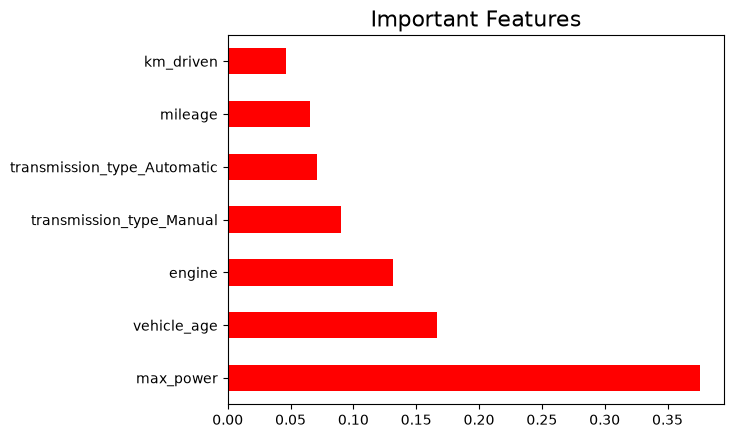

In [43]:
imp_feature = pd.Series(model.feature_importances_, index = X.columns)
imp_feature.nlargest(7).plot(kind = 'barh', color='red')
plt.title('Important Features', fontsize=16)
plt.show()

## 6. Model Building and Evaluation

Multiple regression algorithms are trained and compared using
the same train-test split and evaluation metrics.

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state= 42)

In [45]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score, r2_score

In [46]:
models = [ LinearRegression, SVR, DecisionTreeRegressor, RandomForestRegressor, Ridge, Lasso]
mse = []
rmse = []
evs = []
r_square_score = []

for model in models:
    regressor = model().fit(X_train, y_train)
    pred = regressor.predict(X_test)
    mse.append(mean_squared_error(y_true= y_test, y_pred= pred))
    rmse.append(np.sqrt(mean_squared_error(y_true= y_test, y_pred= pred)))
    evs.append(explained_variance_score(y_true= y_test, y_pred= pred))
    r_square_score.append(r2_score(y_true= y_test, y_pred= pred))

In [47]:
ML_model_df=pd.DataFrame({"Model":[ 'Linear Regression', 'Support Vector Rregression', 'Decision Tree Regressor', \
                                   'Random Forest Regressor', 'Ridge', 'Lasso'],
                         "Mean Squarred Error":mse,
                         "Root Mean Squarred Error":rmse,
                         "Explained Variance Score":evs,
                         "R-Sqaure Score(Accuracy)":r_square_score})

ML_model_df.set_index('Model',inplace=True)
ML_model_df

,Mean Squarred Error,Root Mean Squarred Error,Explained Variance Score,R-Sqaure Score(Accuracy)
Model,,,,
Linear Regression,2.520923e+11,502087.953221,0.665122,0.665119
Support Vector Rregression,8.040549e+11,896691.096631,0.000102,-0.068112
Decision Tree Regressor,9.917382e+10,314918.759069,0.868283,0.868257
Random Forest Regressor,5.453954e+10,233537.025374,0.927567,0.927549
Ridge,2.520957e+11,502091.313977,0.665118,0.665115
Lasso,2.520990e+11,502094.660531,0.665113,0.665110


### Model Comparison

The candidate regression models are compared using the evaluation
metrics calculated above. The model selected for further tuning is
then evaluated again on the test set.

## 7. Hyperparameter Tuning

RandomizedSearchCV is used to search for suitable Random Forest
hyperparameters using cross-validation.

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
import numpy as np

# Define the hyperparameter grid for RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Initialize the RandomForestRegressor
rf = RandomForestRegressor()

# Use RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=100,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the model with the training data
random_search.fit(X_train, y_train)

# Best hyperparameters from the RandomizedSearchCV
best_rf = random_search.best_estimator_

# Make predictions on the test data using the tuned model
y_pred = best_rf.predict(X_test)

# Calculate evaluation metrics for RandomForest
mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)
evs_rf = explained_variance_score(y_test, y_pred)
r2_rf = r2_score(y_test, y_pred)

# Append the results
mse.append(mse_rf)
rmse.append(rmse_rf)
evs.append(evs_rf)
r_square_score.append(r2_rf)

# Print the best hyperparameters and evaluation scores
print(f"Best hyperparameters for RandomForest: {random_search.best_params_}")
print(f"RandomForest MSE: {mse_rf}")
print(f"RandomForest RMSE: {rmse_rf}")
print(f"RandomForest Explained Variance Score: {evs_rf}")
print(f"RandomForest R² Score: {r2_rf}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best hyperparameters for RandomForest: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40, 'bootstrap': False}
RandomForest MSE: 51403984844.191505
RandomForest RMSE: 226724.46900189557
RandomForest Explained Variance Score: 0.931722006302497
RandomForest R² Score: 0.9317146276729205


In [49]:
import pickle

for model_class in models:
    model = model_class()
    regressor = model.fit(X_train, y_train)

    model_filename = f"{model_class.__name__}_model.pkl"

    with open(model_filename, 'wb') as model_file:
        pickle.dump(regressor, model_file)


## 8. Saving and Loading the Final Model

The selected model is saved using Pickle so that it can be loaded
later without retraining.

In [50]:
best_rf

model_filename  = f'best_model.pkl'
with open(model_filename,'wb') as model_file:
    pickle.dump(best_rf,model_file)

In [51]:
# now we gonna use it our trained model
import pickle
model_filename = f'best_model.pkl'
model = pickle.load(open(model_filename, 'rb'))

### Example Test Samples

In [52]:
X_test.iloc[4:7,:]

,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
12058,11,62000,19.70,796,46.3,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
17316,10,35000,13.93,2179,138.0,7,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
15095,7,12000,18.90,1197,82.0,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


### Example Prediction Input

A sample feature vector is created using the same feature order
used during model training.

In [53]:
array = [4,93456,22.77,1498,98.59,5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0]

In [54]:
model.predict([array])

array([753640.])

In [55]:
y_test.to_frame().iloc[4:7,:]

,selling_price
12058,160000
17316,675000
15095,465000
